# Exploratory Data Analysis (EDA)

## Objective
Understand lead characteristics and identify patterns that influence conversion.

## Key Questions
- What differentiates converting vs non-converting leads?
- Which features are most predictive?
- Are there strong behavioral signals?3. Preparation for modeling

## IMPORTS

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

## LOAD DATA

In [2]:
df = pd.read_csv('/Users/omarpiro/ML_DL_Projects/AI_LEAD_SCORE/data/raw/bank+marketing/bank/bank-full.csv', sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Dataset Overview

The dataset contains information about marketing campaigns and client interactions.

Each row represents a potential lead, and the target variable indicates whether the lead converted.

We begin by examining the structure and general characteristics of the dataset.

## SHAPE + OVERVIEW

In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Structure Summary

The dataset contains a substantial number of observations (~45,000 rows) and a mix of numerical and categorical features.

- No missing values were detected
- Data types are consistent and ready for analysis
- Both demographic and behavioral variables are present

👉 This combination makes the dataset well-suited for analyzing lead behavior and building a predictive scoring system.

Overall, the dataset is clean, structured, and representative of real-world marketing scenarios.

## TARGET ANALYSIS

In [5]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [6]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [8]:
df['y'].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

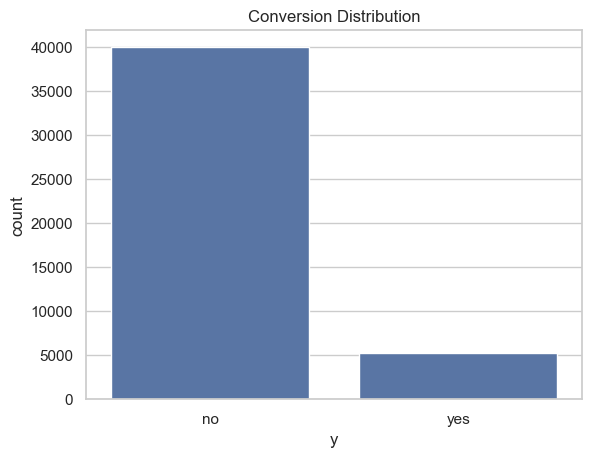

In [7]:
sns.countplot(x='y', data=df)
plt.title("Conversion Distribution")
plt.show()

### Target Distribution

The target variable shows a strong class imbalance:

- A large majority of leads did not convert
- Only a small percentage resulted in conversion

In percentage terms, the conversion rate is low, which is typical in real-world marketing campaigns.

### Implications

- A naive model predicting only "no conversion" could achieve high accuracy
- However, such a model would be useless for business purposes

👉 The real objective is to identify high-potential leads among a large pool of non-converting ones.

Therefore, evaluation metrics such as precision, recall, and ROC-AUC will be more relevant than accu

## FEATURE ANALYSIS

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical features:", list(categorical_cols))
print("Numerical features:", list(numerical_cols))

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## Numerical Features Analysis

We analyze numerical variables to understand how lead characteristics and behaviors vary across the dataset.

Key variables include:
- Age
- Account balance
- Duration of interaction
- Number of contacts

👉 These features may capture engagement and financial capacity, both relevant for conversion.

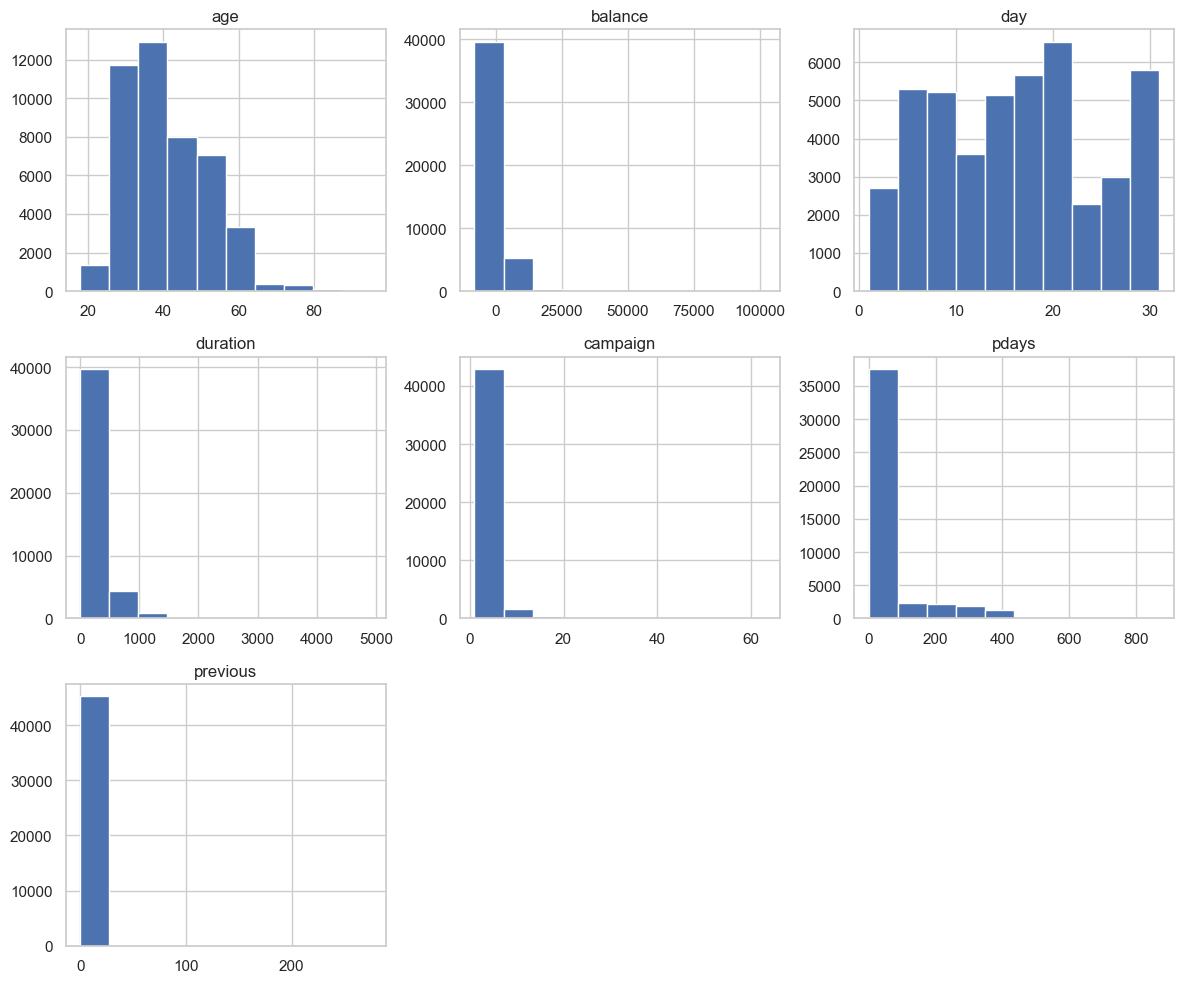

In [11]:
df[numerical_cols].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

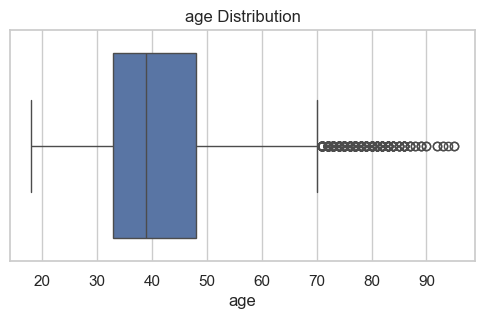

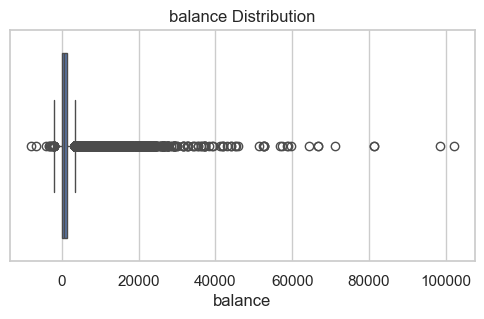

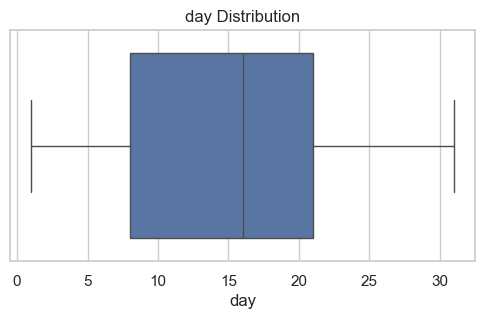

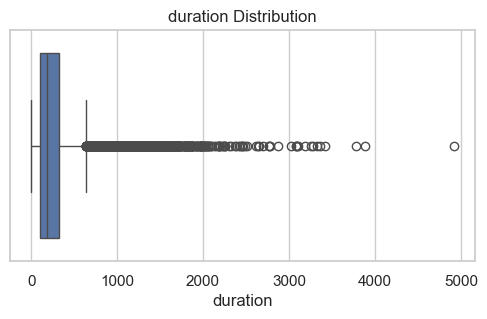

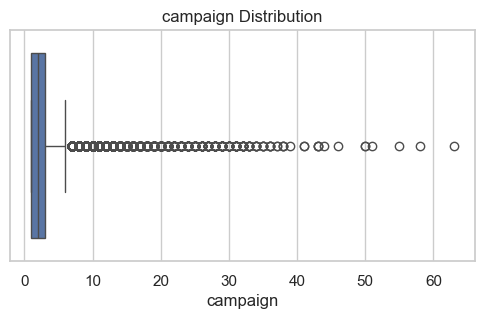

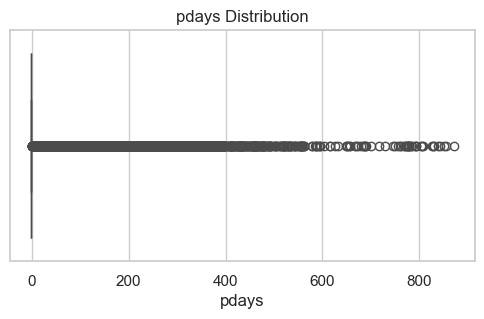

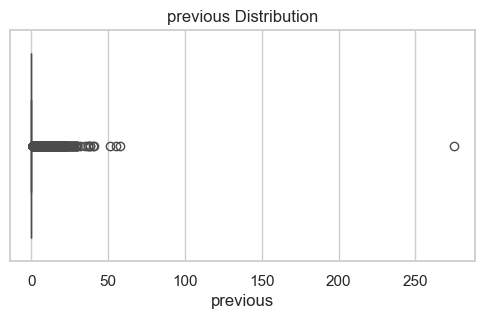

In [12]:
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Distribution")
    plt.show()

In [13]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


### Key Observations (Numerical Features)

- Duration is highly skewed, with most interactions being short but a few very long calls  
👉 Longer interactions may indicate higher engagement and stronger interest  

- Balance shows significant variability, including negative values  
👉 This reflects diverse financial profiles among leads  

- Pdays contains a large concentration of -1 values  
👉 This likely indicates leads that were never contacted before  

- Previous is mostly zero  
👉 Most leads have not been contacted previously  

👉 Overall, engagement-related variables (such as duration and previous interactions) appear more informative than purely demographic variables.

### NUMERICAL FEATURES vs TARGET

We analyze how numerical features influence lead conversion.

This helps identify which quantitative variables are strong indicators of conversion probability.

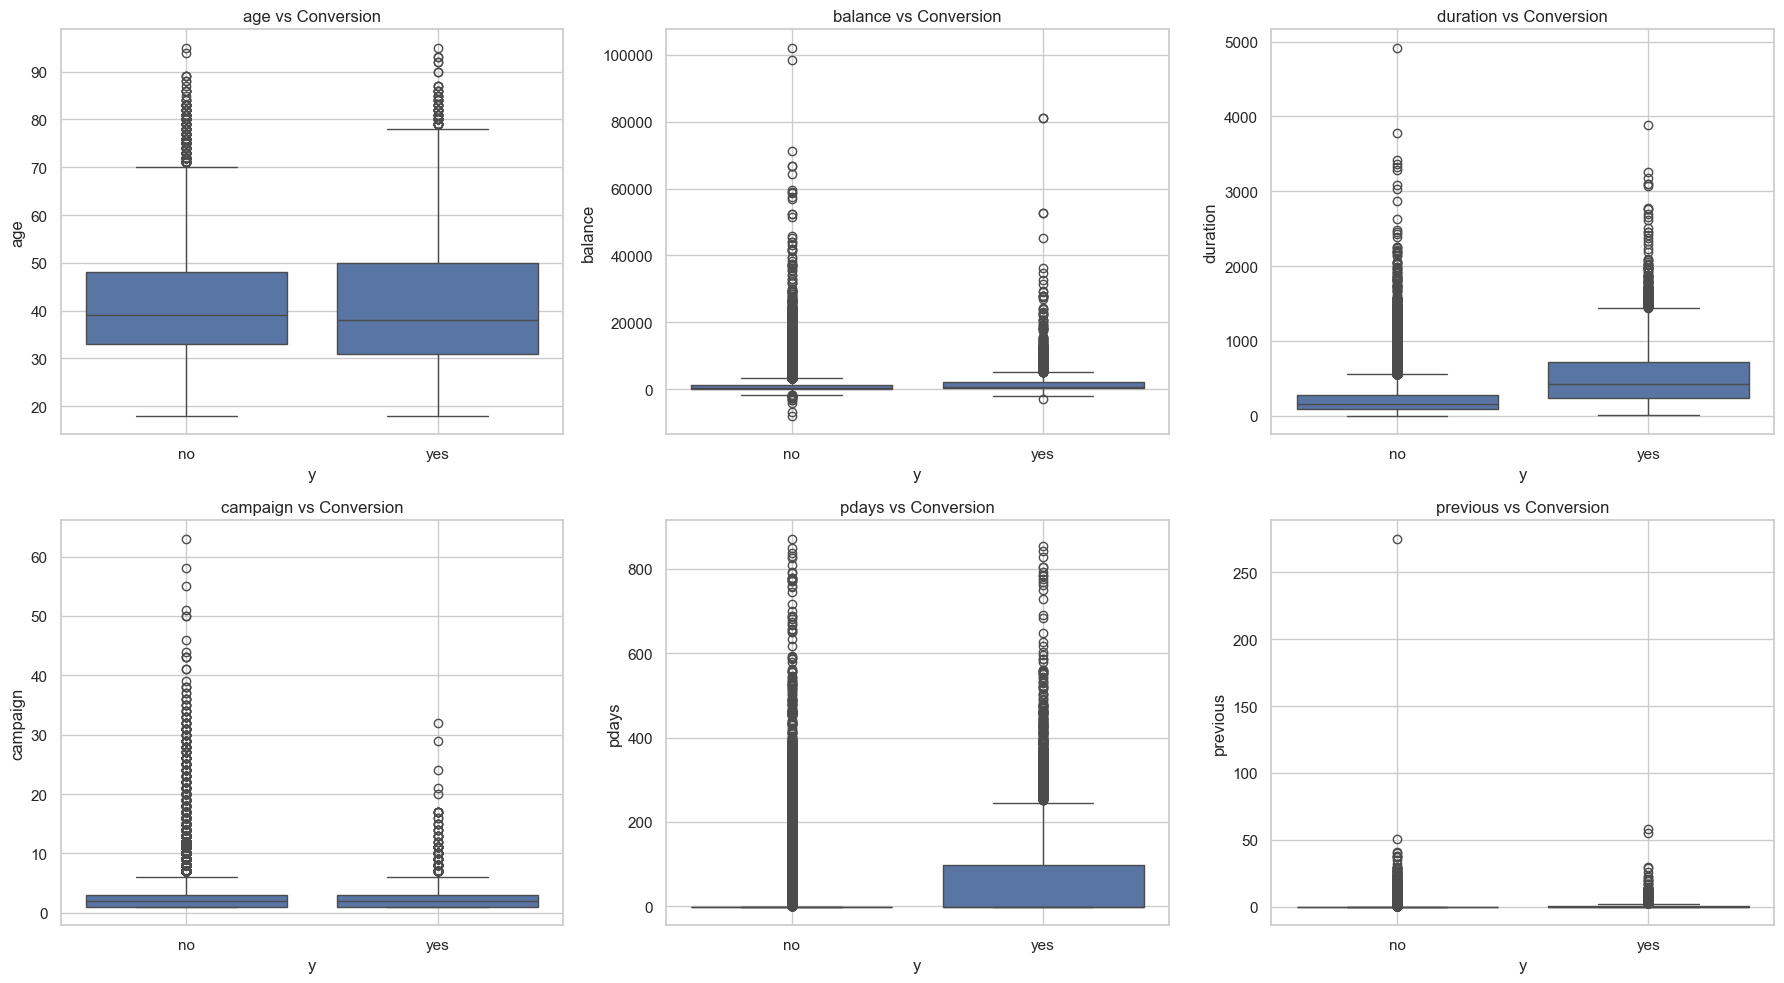

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='y', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Conversion")
    axes[i].grid(True)
plt.tight_layout()
plt.show()

### Key Insights from Numerical Features

From the analysis of numerical features, several important patterns emerge:

- Duration is the strongest signal of conversion  
  Leads with longer interaction durations are significantly more likely to convert  
  👉 This highlights the importance of engagement  

- Previous interactions positively impact conversion  
  Leads that have been contacted before tend to convert more often  
  👉 Familiarity and prior engagement increase trust  

- Campaign intensity shows limited effectiveness  
  Increasing the number of contacts does not significantly improve conversion  
  👉 This suggests diminishing returns from repeated outreach  

- Pdays requires special handling  
  A large portion of values correspond to leads that were never contacted before  
  👉 This feature may need transformation to be meaningful  

- Balance and age show weak predictive power  
  These variables do not clearly separate converting and non-converting leads  
  👉 Demographic and financial variables alone are not sufficient  

### Key Takeaway

👉 Behavioral features (engagement and interaction history) are far more predictive than static demographic attributes.

This insight is critical for designing an effective lead scoring system.

 ## Categorical features analysis

In [19]:
cat_cols = ['job', 'education', 'marital', 'contact', 'poutcome']

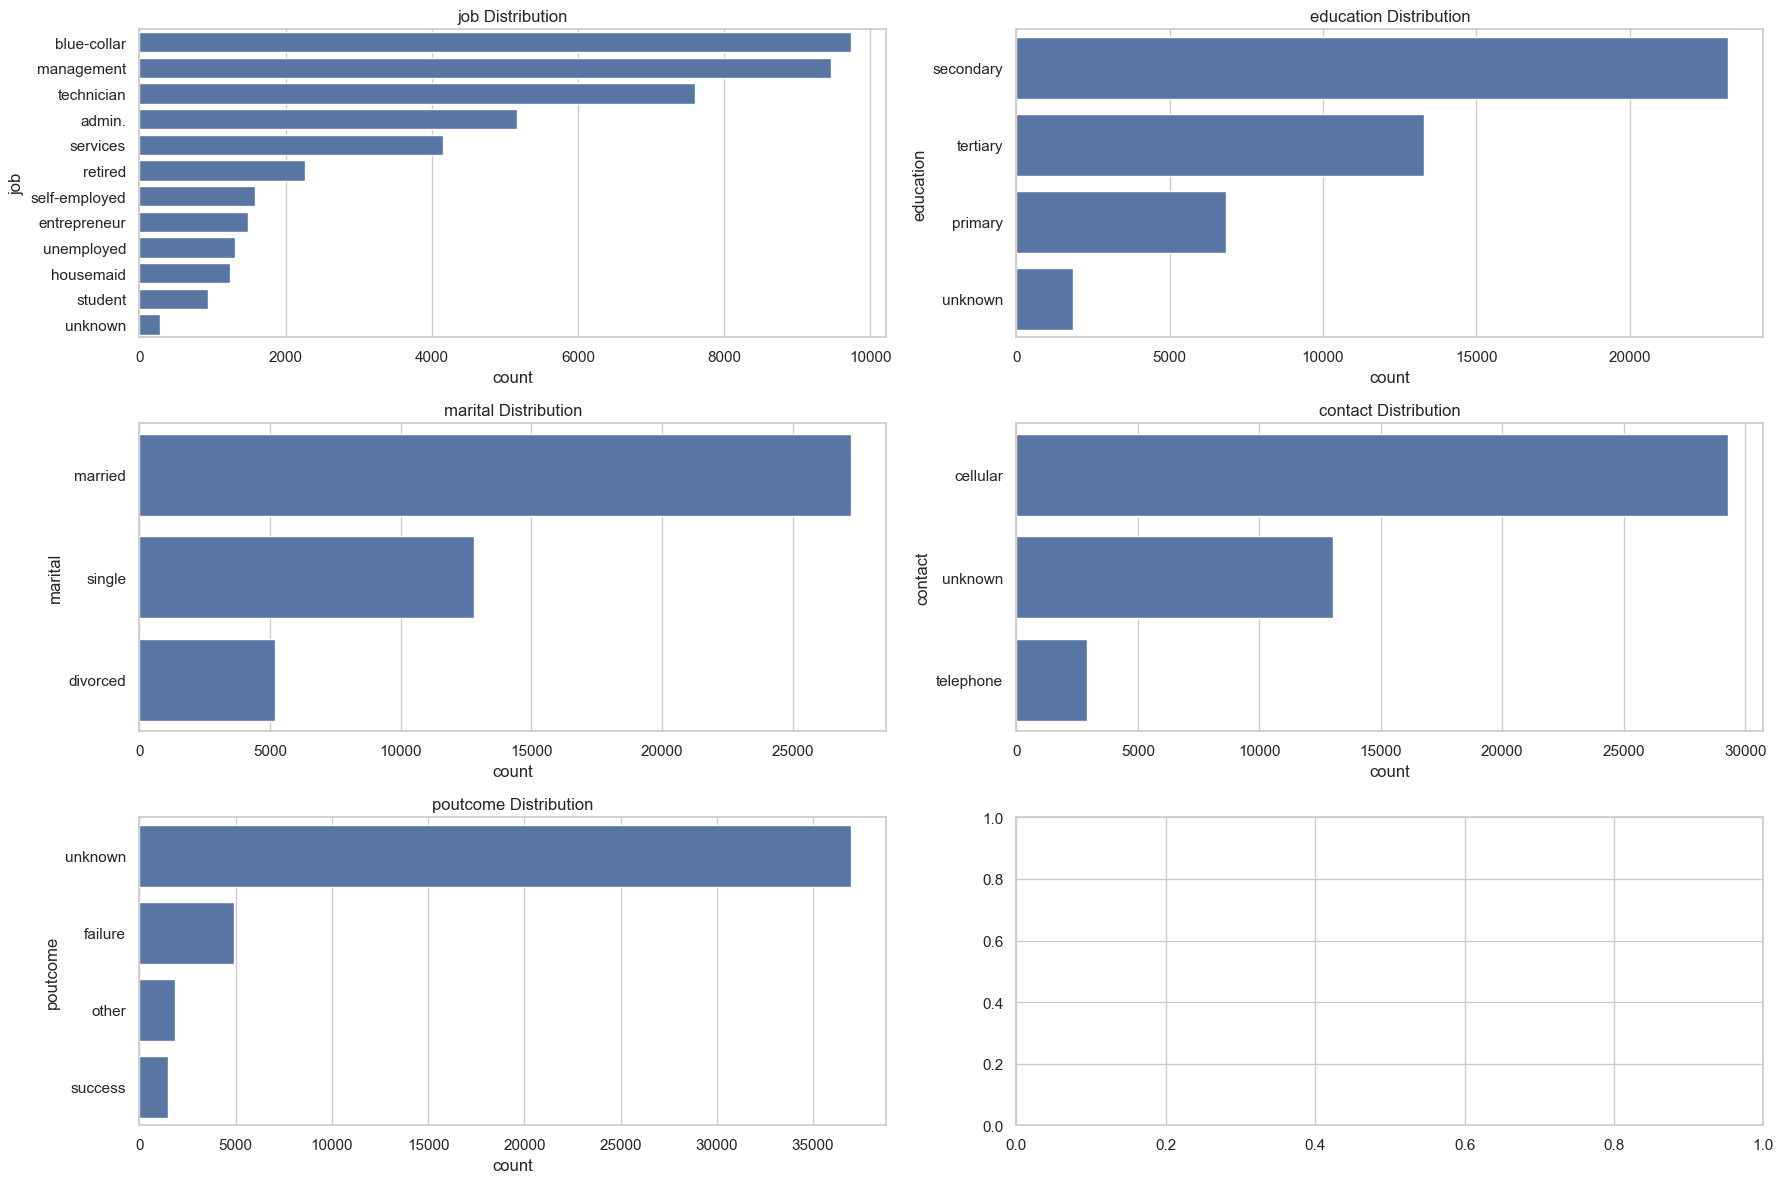

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

In [21]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True))


--- job ---
job
blue-collar      0.215257
management       0.209197
technician       0.168034
admin.           0.114375
services         0.091880
retired          0.050076
self-employed    0.034925
entrepreneur     0.032890
unemployed       0.028820
housemaid        0.027427
student          0.020747
unknown          0.006370
Name: proportion, dtype: float64

--- education ---
education
secondary    0.513194
tertiary     0.294198
primary      0.151534
unknown      0.041074
Name: proportion, dtype: float64

--- marital ---
marital
married     0.601933
single      0.282896
divorced    0.115171
Name: proportion, dtype: float64

--- contact ---
contact
cellular     0.647741
unknown      0.287983
telephone    0.064276
Name: proportion, dtype: float64

--- poutcome ---
poutcome
unknown    0.817478
failure    0.108403
other      0.040698
success    0.033421
Name: proportion, dtype: float64


### Conclusion of Categorical Features Analysis

The analysis of categorical variables reveals several important patterns in the dataset:

- Certain categories (e.g., job, education, and contact type) are more represented than others, indicating an uneven distribution of leads  
- Some variables contain dominant categories (e.g., "unknown" in previous outcomes), which may limit their direct predictive power  
- Categorical features capture important qualitative aspects of leads, such as demographics and communication channels  

👉 However, these features alone do not provide strong separation between converting and non-converting leads.

## Key Takeaway

- Categorical variables provide useful contextual information  
- Their predictive power is generally moderate when used alone  
- They are most effective when combined with behavioral features (e.g., interaction duration, previous contact)

👉 This reinforces the importance of combining multiple feature types in a lead scoring system.

 ### Categorical features vs target 

In [22]:
for col in cat_cols:
    print(f"\n=== {col} ===")
    conversion_rate = pd.crosstab(df[col], df['y'], normalize='index')
    print(conversion_rate)


=== job ===
y                    no       yes
job                              
admin.         0.877973  0.122027
blue-collar    0.927250  0.072750
entrepreneur   0.917283  0.082717
housemaid      0.912097  0.087903
management     0.862444  0.137556
retired        0.772085  0.227915
self-employed  0.881571  0.118429
services       0.911170  0.088830
student        0.713220  0.286780
technician     0.889430  0.110570
unemployed     0.844973  0.155027
unknown        0.881944  0.118056

=== education ===
y                no       yes
education                    
primary    0.913735  0.086265
secondary  0.894406  0.105594
tertiary   0.849936  0.150064
unknown    0.864297  0.135703

=== marital ===
y               no       yes
marital                     
divorced  0.880545  0.119455
married   0.898765  0.101235
single    0.850508  0.149492

=== contact ===
y                no       yes
contact                      
cellular   0.850811  0.149189
telephone  0.865795  0.134205
unknown    0.

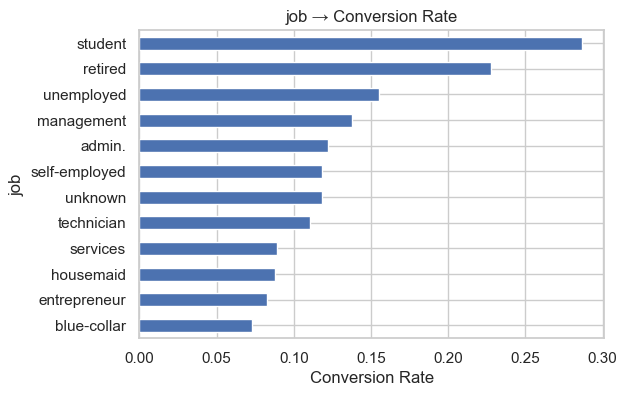

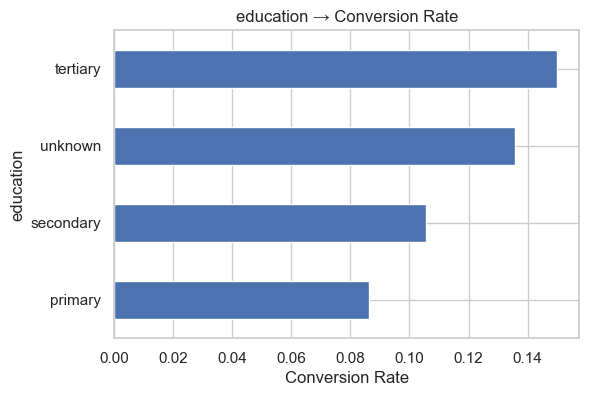

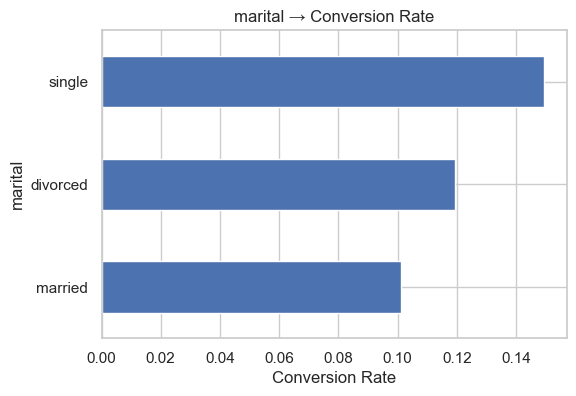

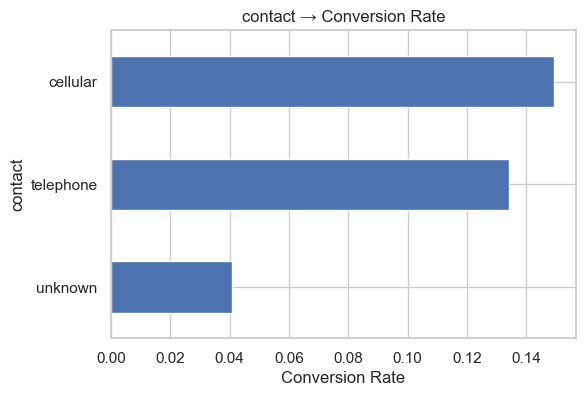

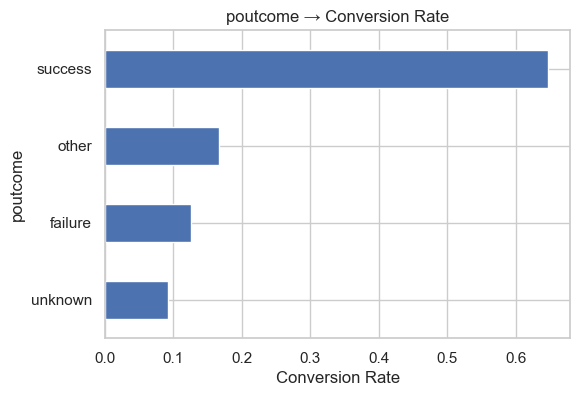

In [24]:
import matplotlib.pyplot as plt

for col in cat_cols:
    conversion_rate = pd.crosstab(df[col], df['y'], normalize='index')
    conversion_rate['yes'].sort_values().plot(kind='barh', figsize=(6,4))
    plt.title(f"{col} → Conversion Rate")
    plt.xlabel("Conversion Rate")
    plt.show()

### Categorical Features vs Conversion

The analysis of categorical variables reveals that conversion rates vary across different lead attributes:

- Job: Conversion rates differ across professions, suggesting that occupation may influence purchasing behavior, although the effect remains moderate  
- Education: Higher education levels show slightly better conversion rates, possibly reflecting differences in financial awareness  
- Marital Status: Only minor variations are observed, indicating limited predictive power when used alone  
- Contact Type: Communication channel has a clear impact on conversion, with some methods performing significantly better than others  
- Previous Outcome: This is one of the strongest categorical predictors — leads with successful past interactions show much higher conversion rates  

👉 Overall, categorical variables provide useful contextual information but are generally less predictive than behavioral features.

## Key Takeaway

- Categorical features contribute to understanding lead profiles  
- Their predictive power increases when combined with behavioral signals  
- Historical interaction outcomes and communication channels are the most informative among them

## Encoding Strategy (Preview)

Categorical features require different encoding strategies depending on their nature:

- Ordinal variables (e.g., education) will be encoded using ordinal encoding to preserve their natural order  
- Nominal variables (e.g., job, marital status, contact type) will be encoded using one-hot encoding to avoid introducing artificial relationships  
- Special cases such as previous outcomes may require custom transformation to capture their predictive signal  

👉 Choosing the right encoding strategy is essential to ensure that the model captures meaningful patterns without introducing bias.

# Final EDA Conclusion

This exploratory analysis provided key insights into lead behavior and conversion patterns.

### Key Findings

- Behavioral features are the strongest predictors of conversion  
  Interaction duration and previous contacts show a clear relationship with conversion outcomes  

- Categorical features provide contextual insights  
  Variables such as contact type and previous campaign outcome influence conversion but with varying strength  

- Demographic features have limited standalone impact  
  Variables like age and balance do not strongly differentiate converting and non-converting leads  

- The dataset is highly imbalanced (~12% conversion rate)  
  This reflects real-world scenarios and requires careful evaluation during modeling  

### Business Implications

- Prioritize leads with strong engagement signals  
- Leverage historical interaction data to improve targeting  
- Optimize communication channels for better conversion outcomes  

👉 These insights highlight the importance of combining behavioral and contextual data in a lead scoring system.

### Next Steps

- Apply appropriate encoding strategies for categorical variables  
- Build and evaluate predictive models  
- Develop a scoring system to rank leads based on conversion probability  

👉 The next phase focuses on transforming these insights into a production-ready lead scoring model.